In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
from sklearn.datasets import make_blobs
from imblearn.over_sampling import SMOTENC

In [5]:
import imblearn.over_sampling

In [6]:
for item in dir(imblearn.over_sampling):
    if 'SMOTE' in item:
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE


In [32]:
random_state=42
centers=[(0,0), (5,5)]
cluster_std = 1.5
n_features=2
n_samples=1600

In [33]:
X, y = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    cluster_std=cluster_std,
    random_state=random_state,
)

X, y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [17]:
?np.random.RandomState

Init signature: np.random.RandomState(self, /, *args, **kwargs)
Docstring:     
RandomState(seed=None)

Container for the slow Mersenne Twister pseudo-random number generator.
Consider using a different BitGenerator with the Generator container
instead.

`RandomState` and `Generator` expose a number of methods for generating
random numbers drawn from a variety of probability distributions. In
addition to the distribution-specific arguments, each method takes a
keyword argument `size` that defaults to ``None``. If `size` is ``None``,
then a single value is generated and returned. If `size` is an integer,
then a 1-D array filled with generated values is returned. If `size` is a
tuple, then an array with that shape is filled and returned.

**Compatibility Guarantee**

A fixed bit generator using a fixed seed and a fixed series of calls to
'RandomState' methods using the same parameters will always produce the
same results up to roundoff error except when the values were incorrect.
`Random

In [ ]:
#rng, Random number generator
rng = np.random.RandomState(42)


In [19]:
dir(rng)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__pyx_vtable__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_bit_generator',
 '_poisson_lam_max',
 'beta',
 'binomial',
 'bytes',
 'chisquare',
 'choice',
 'dirichlet',
 'exponential',
 'f',
 'gamma',
 'geometric',
 'get_state',
 'gumbel',
 'hypergeometric',
 'laplace',
 'logistic',
 'lognormal',
 'logseries',
 'multinomial',
 'multivariate_normal',
 'negative_binomial',
 'noncentral_chisquare',
 'noncentral_f',
 'normal',
 'pareto',
 'permutation',
 'poisson',
 'power',
 'rand',
 'randint',
 'randn',
 'random',
 'random_integers',
 'random_sample',
 'rayleigh',
 'seed',
 'set_state',
 'shuffle',
 'standard_cauchy',
 'standard_exponential',
 'standard_gamma',
 'standard_

In [20]:
?rng.choice

Signature: rng.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a
    single value is returned.
r

In [35]:
X['varC'] = rng.choice(['A','B','C'], size=n_samples).astype(object)
X.head()

,varA,varB,varC
0,-0.4805,0.6362,C
1,-0.8708,0.8829,A
2,4.9604,5.4202,C
3,3.7632,4.0871,C
4,0.2409,0.0046,A


In [36]:
?rng.choice

Signature: rng.choice(a, size=None, replace=True, p=None)
Docstring:
choice(a, size=None, replace=True, p=None)

Generates a random sample from a given 1-D array

.. note::
    New code should use the `~numpy.random.Generator.choice`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

.. warning::
    This function uses the C-long dtype, which is 32bit on windows
    and otherwise 64bit on 64bit platforms (and 32bit on 32bit ones).
    Since NumPy 2.0, NumPy's default integer is 32bit on 32bit platforms
    and 64bit on 64bit platforms.


Parameters
----------
a : 1-D array-like or int
    If an ndarray, a random sample is generated from its elements.
    If an int, the random sample is generated as if it were ``np.arange(a)``
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a
    single value is returned.
r

In [39]:
X['varD'] = rng.choice(a=['Blue', 'Green', 'Red'],size=n_samples).astype(object)
X.head()

,varA,varB,varC,varD
0,-0.4805,0.6362,C,Blue
1,-0.8708,0.8829,A,Red
2,4.9604,5.4202,C,Red
3,3.7632,4.0871,C,Green
4,0.2409,0.0046,A,Blue


In [40]:
X.shape, y.shape

((1600, 4), (1600,))

In [ ]:
#Downsampling target variable == 1
data1 = X[y==0]
data2 = X[y==1].sample(200, random_state=0)

In [44]:
X = pd.concat([data1, data2],axis=0)

In [46]:

X.shape, y.shape

((1000, 4), (1600,))

In [50]:
y=y.loc[X.index]

In [51]:
X.shape, y.shape

((1000, 4), (1000,))

In [52]:
X.head(10)

,varA,varB,varC,varD
0,-0.4805,0.6362,C,Blue
1,-0.8708,0.8829,A,Red
4,0.2409,0.0046,A,Blue
9,-0.6951,-0.6986,C,Blue
10,2.1042,-2.1028,C,Red
11,-0.8328,2.8217,C,Red
12,1.8196,0.2126,A,Green
14,0.4403,-2.0349,B,Red
15,-0.0285,-1.5038,A,Green
16,3.8401,-0.1441,B,Blue


In [53]:
X.dtypes

varA    float64
varB    float64
varC     object
varD     object
dtype: object

In [54]:
from my_functions import Scatterplot

In [57]:
X.iloc[:,:2]

,varA,varB
0,-0.4805,0.6362
1,-0.8708,0.8829
4,0.2409,0.0046
9,-0.6951,-0.6986
10,2.1042,-2.1028
...,...,...
1291,4.6118,7.3980
1055,3.6257,3.7523
723,4.9074,5.7192
37,4.3805,3.6100


In [59]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

>>>Scatterplot(X, y, X_resampled, y_resampled)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

In [63]:
X.head()

,varA,varB,varC,varD
0,-0.4805,0.6362,C,Blue
1,-0.8708,0.8829,A,Red
4,0.2409,0.0046,A,Blue
9,-0.6951,-0.6986,C,Blue
10,2.1042,-2.1028,C,Red


In [72]:
def Scatterplot(data1, class1, data2, class2, alpha=None):
    '''
    Plot 2 Scatterplots.
    1 Row and 2 columns, given the 2 provided datasets
    Ex:

    Without alpha:
    >>>Scatterplot(X, y, X_resampled, y_resampled)

    With alpha:
    >>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)

    '''
    
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    sns.scatterplot(data=data1, x=data1.columns[0], y=data1.columns[1], alpha=alpha, hue=class1)

    plt.subplot(122)
    sns.scatterplot(data=data2, x=data2.columns[0], y=data2.columns[1], alpha=alpha,hue=class2)

In [73]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      /tmp/ipykernel_11193/275819057.py
Type:      function

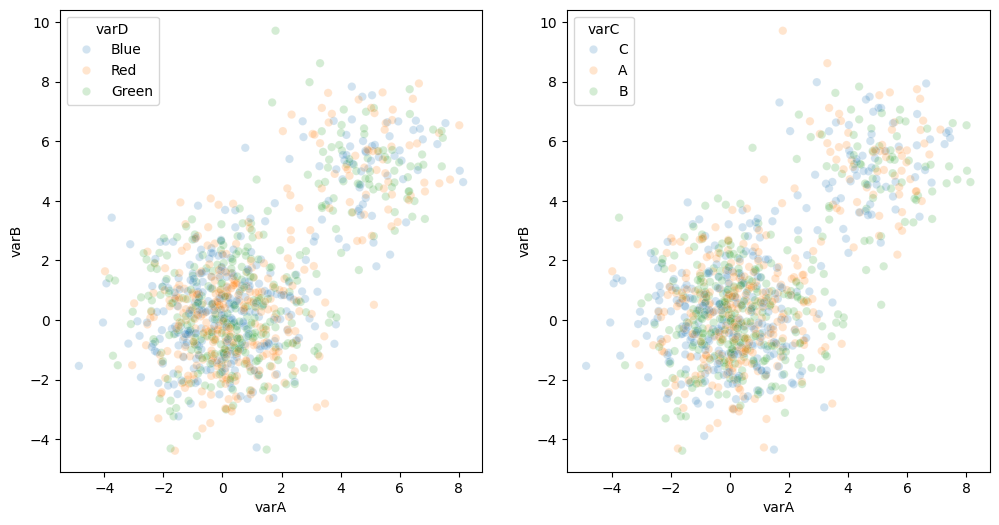

In [68]:
Scatterplot(X.iloc[:,:2],X.varD, X.iloc[:,:2],X.varC, alpha=0.2)

# SMOTE-NC

In [74]:
for item in dir(imblearn.over_sampling):
    if 'SMOTE' in item:
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE


In [75]:
from imblearn.over_sampling import SMOTENC

In [77]:
X.dtypes

varA    float64
varB    float64
varC     object
varD     object
dtype: object

In [86]:
smc = SMOTENC(
    categorical_features=[2,3],
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
)

X_resampled, y_resampled = smc.fit_resample(X,y)

In [ ]:
X.shape, X_resampled.shape

((1000, 4), (1600, 4))

In [ ]:
y.value_counts(), y_resampled.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64)

In [84]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      /tmp/ipykernel_11193/275819057.py
Type:      function

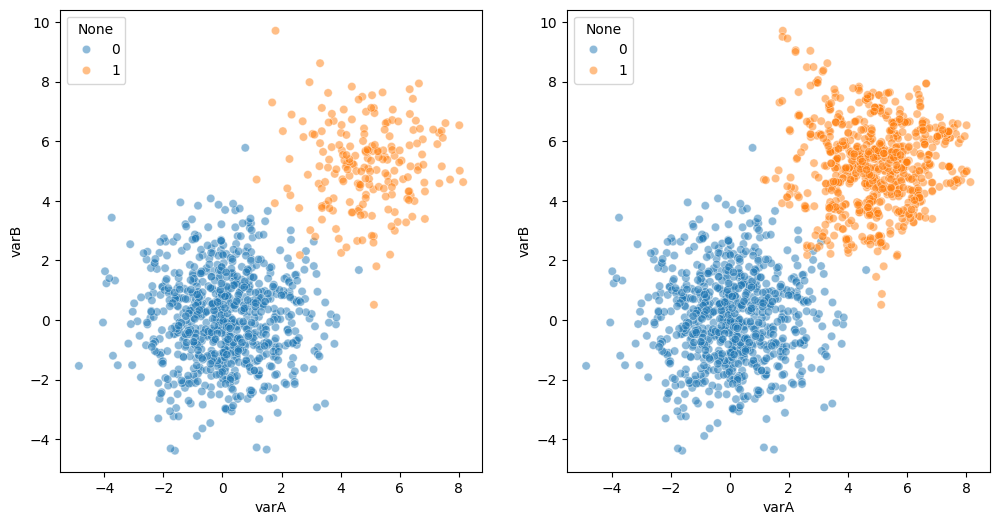

In [87]:
Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)